## 5.2 Summary Report for RQ2

Comparing Large and Small Langiage model

In [11]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score
import json
import re
import io

# Ensure plot variables are available for independent summary execution
MODEL_COLORS = {
    "anthropic": "#C45A8A",
    "openai":    "#10A37F",
    "gemini":    "#4285F4",
    "llama":     "#E07B39",
    "qwen":      "#9B59B6",
    "mistral":   "#F1C40F",
}
FRONTIER_MODELS = ["anthropic", "openai", "gemini"]
OPEN_MODELS     = ["llama", "qwen", "mistral"]
ALL_MODELS      = FRONTIER_MODELS + OPEN_MODELS

# --- 1. Load Text Volume / Richness Data ---
FILE_MAP = {
    "anthropic": "cs_pck_results_anthropic.json",
    "openai":    "cs_pck_results_openai.json",
    "gemini":    "cs_pck_results_gemini.json",
    "llama":     "cs_pck_results_llama.json",
    "qwen":      "cs_pck_results_qwen38.json",
    "mistral":   "cs_pck_results_mistral.json",
}
raw_data = {}
for model, filename in FILE_MAP.items():
    with open(filename, "r", encoding="utf-8") as f:
        raw_data[model] = json.load(f)

# --- 2. Load Human Evaluator Ratings ---
with open("python.json", "r") as f:
    eval_data_python = json.loads(f.read().replace("qwen38", "qwen"))
try:
    with open("scratch.json", "r") as f:
        eval_data_scratch = json.loads(f.read().replace("qwen38", "qwen"))
except FileNotFoundError:
    eval_data_scratch = None

# --- 3. Load Pedagogical Content Data (ratings.xlsx) ---
def parse_ratings_summary(val):
    if pd.isna(val) or str(val).strip() in ['–', '-', '']:
        return None
    nums = re.findall(r'\d+', str(val).strip())
    return [int(n) for n in nums] if nums else None

sheets = pd.read_excel('ratings.xlsx', sheet_name=None, header=None)
rows_ratings = []
for sheet_name, df_sheet in sheets.items():
    pck_labels = [str(df_sheet.iloc[0, c]).strip() for c in range(1, df_sheet.shape[1], 2)]
    for r in range(2, df_sheet.shape[0]):
        model = str(df_sheet.iloc[r, 0]).strip()
        for i, pck in enumerate(pck_labels):
            c = 1 + i*2
            for rater_idx, col in enumerate([c, c+1], 1):
                if col < df_sheet.shape[1]:
                    rtgs = parse_ratings_summary(df_sheet.iloc[r, col])
                    if rtgs:
                        for score in rtgs:
                            rows_ratings.append({'model': model, 'pck': pck, 'rater': rater_idx, 'score': score})

df_ratings = pd.DataFrame(rows_ratings)
# Globally rename qwen38 to qwen in the loaded dataframe
df_ratings['model'] = df_ratings['model'].replace('qwen38', 'qwen')

# --- 4. Load Correctness Data ---
csv_data = """PCK #,Topic,Model A,Model G,Model L,Model M,Model O,Model Q
PCK1,Variables,Yes,Yes,Yes,Yes,Yes,Yes
PCK2,Loops,Yes,Yes,Yes,Yes,Yes,No
PCK3,Conditionals,Yes,Yes,No,No,Yes,Yes
PCK4,Boolean Logic,Yes,Yes,Yes,Yes,Yes,Yes
PCK5,Boolean Logic,Yes,Yes,Yes,Yes,Yes,Yes
PCK6,Loops,Yes,Yes,Yes,No,Yes,Yes
PCK7,Computational Arithmetic (Order of Operations),Yes,Yes,Yes,No,Yes,Yes
PCK8,Computational Arithmetic (Casting),No,No,No,No,Yes,Yes
PCK9,Computational Arithmetic (Order of Operations),No,No,No,No,No,No
PCK10,Boolean Logic,Yes,Yes,No,No,Yes,Yes
PCK11,Loops,Yes,Yes,Yes,No,Yes,Yes
PCK12,Functions,Yes,Yes,Yes,Yes,Yes,Yes
PCK13,Conditionals / Data Structures,Yes,Yes,No,No,Yes,Yes"""
df_correct = pd.read_csv(io.StringIO(csv_data))

print("\u2705 Setup complete for Summary Report - All data loaded independently")

✅ Setup complete for Summary Report - All data loaded independently


### 5.2.1 Text Volume and Richness

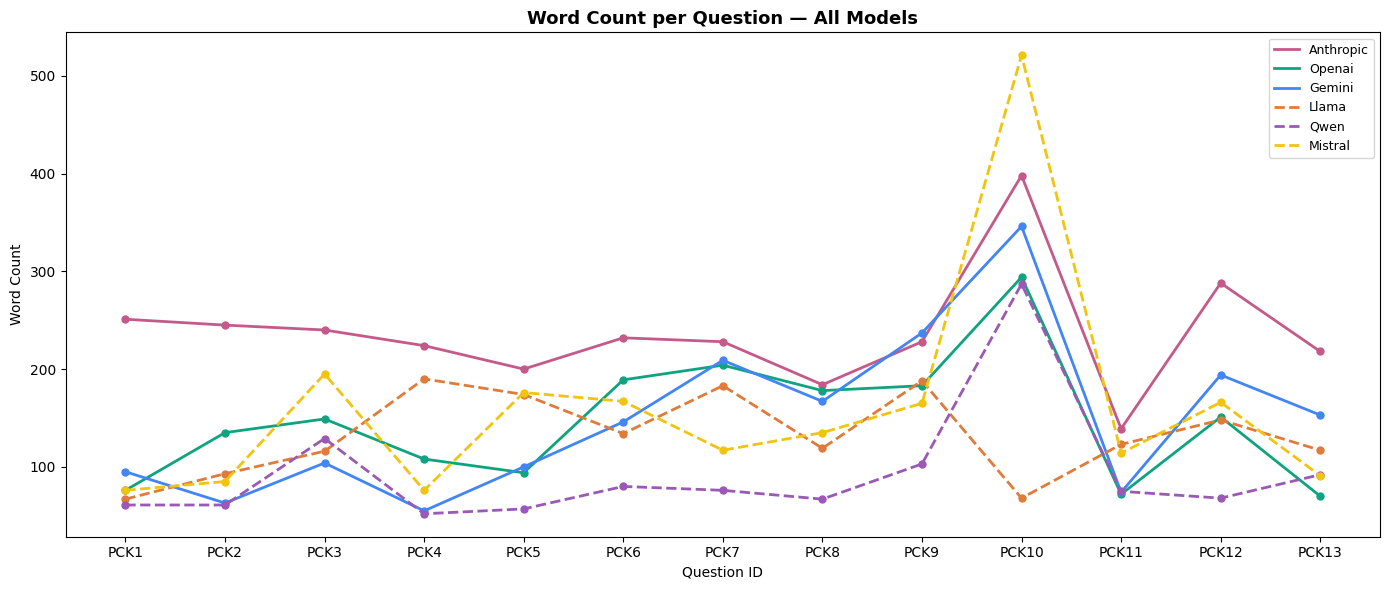

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Redefine rows directly from raw_data for complete independence
rows = []
for model, questions in raw_data.items():
    for qid, answer in questions.items():
        rows.append({
            "model": model,
            "question": qid,
            "words": len(answer.strip('"').split())
        })

# Rebuild the text dataframe
text_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(14, 6))

question_order = [f"PCK{i}" for i in range(1, 14)]

for model in ALL_MODELS:
    model_df = text_df[text_df["model"] == model].set_index("question").reindex(question_order)
    ls = "-" if model in FRONTIER_MODELS else "--"
    ax.plot(
        question_order, model_df["words"],
        label=model.capitalize(), color=MODEL_COLORS[model],
        linestyle=ls, linewidth=2, marker="o", markersize=5,
    )

ax.set_title("Word Count per Question — All Models", fontsize=13, fontweight="bold")
ax.set_xlabel("Question ID")
ax.set_ylabel("Word Count")
ax.legend(loc="upper right", fontsize=9)

# Legend note for line styles
ax.legend(handles=[*[plt.Line2D([0],[0], color=MODEL_COLORS[m], linewidth=2,
                                 linestyle="-" if m in FRONTIER_MODELS else "--",
                                 label=m.capitalize()) for m in ALL_MODELS]],
          fontsize=9, loc="upper right")

plt.tight_layout()
plt.show()

Question: Do the models differ significantly in text volume and richness?



,H-Statistic,p-value,Significant (p < 0.05)
Metric,,,
Words,28.71,< 0.001,Yes
Sentences,17.85,0.003,Yes
TTR,13.34,0.020,Yes



Question: How does the vocabulary size and Type-Token Ratio (TTR) compare across models?



,group,total_words,unique_words,ttr_corpus
model,,,,
Anthropic,Frontier,2584,572,0.2214
Openai,Frontier,1523,346,0.2272
Gemini,Frontier,1594,410,0.2572
Llama,Open/Small,1596,323,0.2024
Qwen,Open/Small,942,292,0.3100
Mistral,Open/Small,1821,404,0.2219


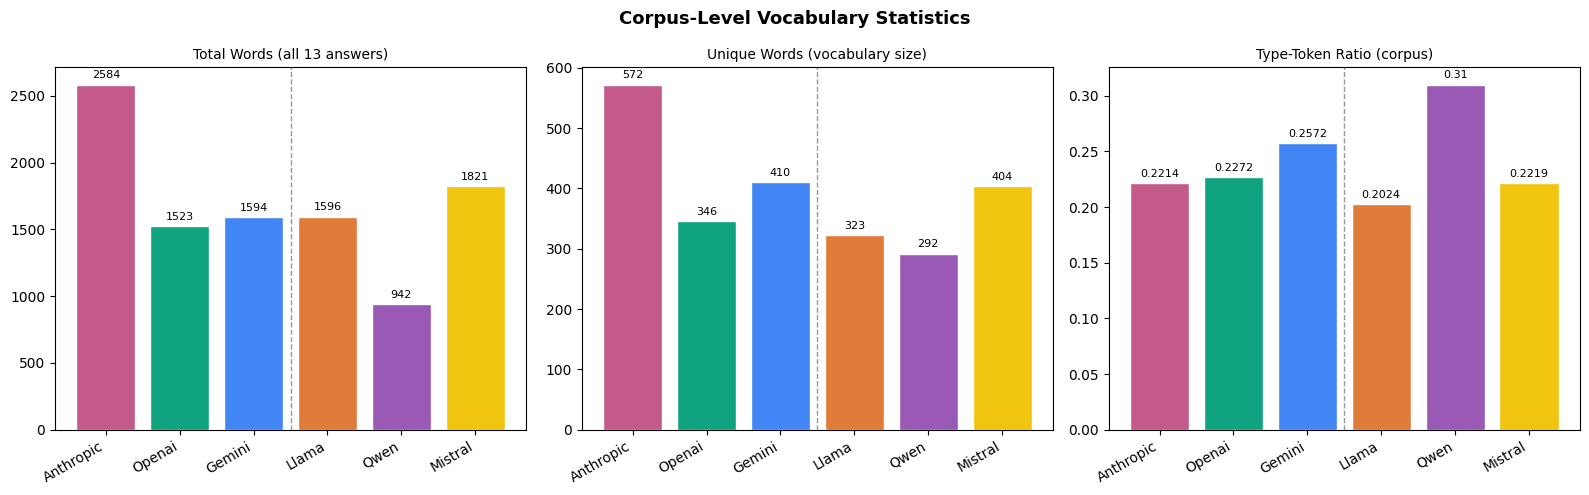

In [13]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

print("Question: Do the models differ significantly in text volume and richness?\n")

# Kruskal-Wallis H-Test Results
kw_data = [
    {"Metric": "Words", "H-Statistic": 28.71, "p-value": "< 0.001", "Significant (p < 0.05)": "Yes"},
    {"Metric": "Sentences", "H-Statistic": 17.85, "p-value": "0.003", "Significant (p < 0.05)": "Yes"},
    {"Metric": "TTR", "H-Statistic": 13.34, "p-value": "0.020", "Significant (p < 0.05)": "Yes"}
]
display(pd.DataFrame(kw_data).set_index("Metric"))

print("\nQuestion: How does the vocabulary size and Type-Token Ratio (TTR) compare across models?\n")

# Calculate vocab_df independently
vocab_rows = []
for model in ALL_MODELS:
    all_text  = " ".join(raw_data[model].values())
    all_words = re.findall(r"[a-zA-Z]+", all_text.lower())
    vocab_rows.append({
        "model":        model.capitalize(),
        "group":        "Frontier" if model in FRONTIER_MODELS else "Open/Small",
        "total_words":  len(all_words),
        "unique_words": len(set(all_words)),
        "ttr_corpus":   round(len(set(all_words)) / len(all_words), 4)
    })

vocab_df = pd.DataFrame(vocab_rows).set_index("model")
display(vocab_df)

# Display the corpus plot correctly
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Corpus-Level Vocabulary Statistics", fontsize=13, fontweight="bold")

for ax, col, title in zip(
    axes,
    ["total_words", "unique_words", "ttr_corpus"],
    ["Total Words (all 13 answers)", "Unique Words (vocabulary size)", "Type-Token Ratio (corpus)"],
):
    vals   = vocab_df[col]
    colors = [MODEL_COLORS[m.lower()] for m in vocab_df.index]
    bars   = ax.bar(vocab_df.index, vals, color=colors, edgecolor="white")
    ax.axvline(x=2.5, color="#555", linestyle="--", linewidth=1, alpha=0.6)
    ax.bar_label(bars, fmt="%.4g", padding=3, fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(len(vocab_df)))
    ax.set_xticklabels(vocab_df.index, rotation=30, ha="right")

plt.tight_layout()
plt.show()

### 5.2.2 Content Correctness

Question: Is there a significant difference in the correctness of the models' answers?

⚗️ Chi-Square Test Results:
➤ Chi-Square Statistic: 14.26
➤ p-value:              0.0141
➤ Degrees of Freedom:   5



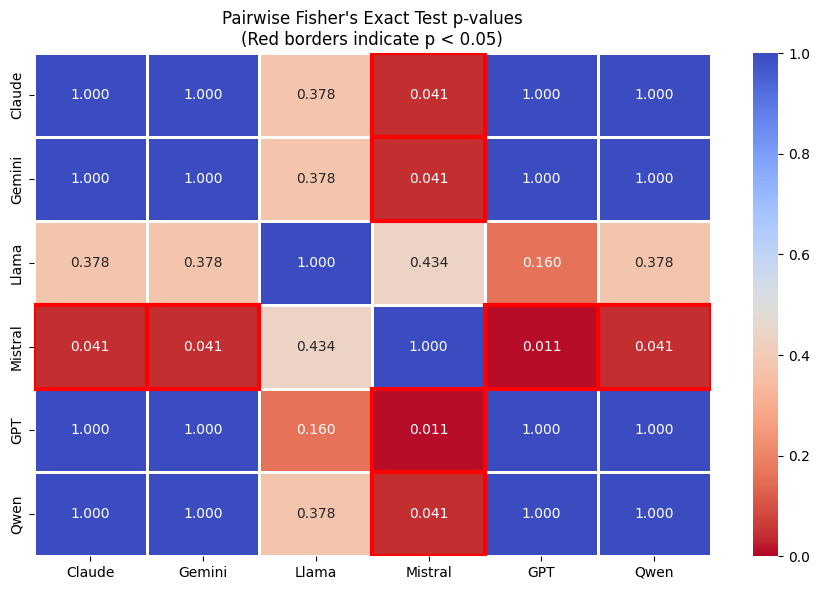

In [14]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

print("Question: Is there a significant difference in the correctness of the models' answers?\n")

# 1. Contingency Table & Chi-Square
models = ['Model A', 'Model G', 'Model L', 'Model M', 'Model O', 'Model Q']
yes_counts = [(df_correct[m] == 'Yes').sum() for m in models]
no_counts = [(df_correct[m] == 'No').sum() for m in models]
contingency_table = pd.DataFrame({'Correct (Yes)': yes_counts, 'Incorrect (No)': no_counts}, index=models)

chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\u2697\ufe0f Chi-Square Test Results:")
print(f"\u27a4 Chi-Square Statistic: {chi2_stat:.2f}")
print(f"\u27a4 p-value:              {p_val:.4f}")
print(f"\u27a4 Degrees of Freedom:   {dof}\n")

# 2. Pairwise Fisher's Exact Test
n_models = len(models)
p_values = np.zeros((n_models, n_models))
for i in range(n_models):
    for j in range(n_models):
        if i == j:
            p_values[i, j] = 1.0
        else:
            table = [contingency_table.iloc[i].values, contingency_table.iloc[j].values]
            _, p = stats.fisher_exact(table)
            p_values[i, j] = p

model_name_map = {'Model A': 'Claude', 'Model G': 'Gemini', 'Model L': 'Llama', 'Model M': 'Mistral', 'Model O': 'GPT', 'Model Q': 'Qwen'}
display_names = [model_name_map.get(m, m) for m in models]
p_val_df = pd.DataFrame(p_values, index=display_names, columns=display_names)

# Plotting Heatmap
plt.figure(figsize=(9, 6))
ax = sns.heatmap(p_val_df, annot=True, cmap="coolwarm_r", vmin=0, vmax=1, fmt=".3f", linewidths=1, linecolor='white')
for i in range(n_models):
    for j in range(n_models):
        if p_val_df.iloc[i, j] < 0.05:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='red', lw=3))
plt.title("Pairwise Fisher's Exact Test p-values\n(Red borders indicate p < 0.05)")
plt.tight_layout()
plt.show()


### 5.2.3 Human Evaluator Ratings

In [15]:
import numpy as np
from sklearn.metrics import cohen_kappa_score

print("Question: What is the inter-rater reliability among human evaluators?\n")

# Helper to parse python.json / scratch.json independently
def normalize_input(payload):
    if "ratings" in payload and "metadata" in payload:
        return payload["ratings"], payload["metadata"]["raters"], payload["metadata"]["packs"], payload["metadata"]["models"], payload.get("scale", [1, 2, 3, 4])

    raw_parsed = {}
    for rater, pack_map in payload.items():
        raw_parsed[rater] = {}
        for pack, model_map in pack_map.items():
            raw_parsed[rater][pack] = {}
            for model, entry in model_map.items():
                if isinstance(entry, dict) and "ratings" in entry:
                    raw_parsed[rater][pack][model] = entry.get("ratings")
                else:
                    raw_parsed[rater][pack][model] = entry

    raters = sorted(raw_parsed.keys())
    packs = sorted({p for r in raw_parsed.values() for p in r.keys()})
    disc_models = {m for r in raw_parsed.values() for p in r.values() for m in p.keys()}
    canonical_models = ["anthropic", "openai", "gemini", "llama", "mistral", "qwen"]
    models = [m for m in canonical_models if m in disc_models] + sorted(disc_models - set(canonical_models))

    return raw_parsed, raters, packs, models, [1, 2, 3, 4]

# Helper to align ratings
def get_paired_ratings(raw_dict, raters_list, packs_list, models_subset):
    a_vals, b_vals = [], []
    rater_a, rater_b = raters_list[0], raters_list[1]
    for pack in packs_list:
        for model in models_subset:
            ra = raw_dict.get(rater_a, {}).get(pack, {}).get(model)
            rb = raw_dict.get(rater_b, {}).get(pack, {}).get(model)
            if ra is None or rb is None:
                continue
            n = min(len(ra), len(rb))
            a_vals.extend(ra[:n])
            b_vals.extend(rb[:n])
    return a_vals, b_vals

def weighted_kappa_quadratic(a, b):
    if len(a) < 2: return np.nan, len(a)
    return cohen_kappa_score(a, b, weights="quadratic"), len(a)

# Calculate for Python Evaluators
raw_py, RATERS_py, PACKS_py, MODELS_py, SCALE_py = normalize_input(eval_data_python)
a_vals, b_vals = get_paired_ratings(raw_py, RATERS_py, PACKS_py, MODELS_py)
kappa, n = weighted_kappa_quadratic(a_vals, b_vals)
print(f"\u27a4 Python Evaluators Quadratic Weighted Kappa = {kappa:.3f} (n={n} pairs)")

# If scratch data is available
if eval_data_scratch:
    raw_sc, RATERS_sc, PACKS_sc, MODELS_sc, SCALE_sc = normalize_input(eval_data_scratch)
    a_vals_sc, b_vals_sc = get_paired_ratings(raw_sc, RATERS_sc, PACKS_sc, MODELS_sc)
    kappa_sc, n_sc = weighted_kappa_quadratic(a_vals_sc, b_vals_sc)
    print(f"\u27a4 Scratch Evaluators Quadratic Weighted Kappa = {kappa_sc:.3f} (n={n_sc} pairs)")


Question: What is the inter-rater reliability among human evaluators?

➤ Python Evaluators Quadratic Weighted Kappa = 0.409 (n=110 pairs)
➤ Scratch Evaluators Quadratic Weighted Kappa = 0.756 (n=120 pairs)


### 5.2.4 Pedagogical Content

In [18]:
import pandas as pd
import scipy.stats as stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests

print("Question: Do the models differ in their pedagogical content scores?\n")

def analyze_pedagogical_content(df_subset, title):
    print(f"--- {title} ---")
    groups = [grp['score'].values for _, grp in df_subset.groupby('model')]
    if not groups:
        print("No data found.\n")
        return

    stat, p = stats.kruskal(*groups)
    print(f"\u2697\ufe0f Kruskal-Wallis H = {stat:.3f}, p-value = {p:.4f}\n")

    # Pairwise Comparisons (Mann-Whitney U with Holm-Bonferroni correction)
    MODEL_ORDER = ['anthropic', 'gemini', 'openai', 'llama', 'mistral', 'qwen']
    pairs = list(combinations(MODEL_ORDER, 2))
    results = []

    for m1, m2 in pairs:
        a = df_subset[df_subset['model']==m1]['score'].values
        b = df_subset[df_subset['model']==m2]['score'].values
        if len(a) > 0 and len(b) > 0:
            u, p_raw = stats.mannwhitneyu(a, b, alternative='two-sided')
            results.append({'model_A': m1, 'model_B': m2, 'U': round(u,1), 'p_raw': p_raw})

    res_df = pd.DataFrame(results)
    if not res_df.empty:
        reject, pvals_corrected, _, _ = multipletests(res_df['p_raw'], alpha=0.05, method='holm')
        res_df['p_holm'] = pvals_corrected
        res_df['sig'] = ['\u2713' if r else '\u2717' for r in reject]

        means = df_subset.groupby('model')['score'].mean().round(3).to_dict()
        res_df['mean_A'] = res_df['model_A'].map(means)
        res_df['mean_B'] = res_df['model_B'].map(means)

        display_df = res_df[['model_A','mean_A','model_B','mean_B','U','p_raw','p_holm','sig']].copy()
        display_df.columns = ['Model A','Mean A','Model B','Mean B','U','p (raw)','p (Holm)','Sig?']
        display_df = display_df.round({'p (raw)': 4, 'p (Holm)': 4})
        display(display_df)
    print("\n")

# Split data by topic area
df_scratch = df_ratings[df_ratings['pck'].isin([f'PCK{i}' for i in range(1, 7)])]
df_python = df_ratings[df_ratings['pck'].isin([f'PCK{i}' for i in range(7, 14)])]

analyze_pedagogical_content(df_scratch, "A) Scratch (PCK1-6)")
analyze_pedagogical_content(df_python, "B) Python (PCK7-13)")

Question: Do the models differ in their pedagogical content scores?

--- A) Scratch (PCK1-6) ---
⚗️ Kruskal-Wallis H = 5.261, p-value = 0.3848



,Model A,Mean A,Model B,Mean B,U,p (raw),p (Holm),Sig?
0,anthropic,1.750,gemini,1.896,1085.5,0.5578,1.0000,✗
1,anthropic,1.750,openai,1.646,1198.5,0.6651,1.0000,✗
2,anthropic,1.750,llama,1.550,1030.0,0.4493,1.0000,✗
3,anthropic,1.750,mistral,1.719,768.5,1.0000,1.0000,✗
4,anthropic,1.750,qwen,2.071,875.5,0.2085,1.0000,✗
5,gemini,1.896,openai,1.646,1265.5,0.3054,1.0000,✗
6,gemini,1.896,llama,1.550,1088.0,0.1832,1.0000,✗
7,gemini,1.896,mistral,1.719,816.5,0.5735,1.0000,✗
8,gemini,1.896,qwen,2.071,933.0,0.4887,1.0000,✗
9,openai,1.646,llama,1.550,990.0,0.7401,1.0000,✗




--- B) Python (PCK7-13) ---
⚗️ Kruskal-Wallis H = 11.894, p-value = 0.0363



,Model A,Mean A,Model B,Mean B,U,p (raw),p (Holm),Sig?
0,anthropic,2.735,gemini,2.176,714.5,0.0796,0.7959,✗
1,anthropic,2.735,openai,2.452,804.0,0.3227,1.0000,✗
2,anthropic,2.735,llama,1.800,472.0,0.0135,0.2029,✗
3,anthropic,2.735,mistral,1.333,160.0,0.0217,0.3033,✗
4,anthropic,2.735,qwen,2.595,769.5,0.5454,1.0000,✗
5,gemini,2.176,openai,2.452,638.5,0.4075,1.0000,✗
6,gemini,2.176,llama,1.800,390.0,0.3450,1.0000,✗
7,gemini,2.176,mistral,1.333,138.0,0.1507,1.0000,✗
8,gemini,2.176,qwen,2.595,590.5,0.1778,1.0000,✗
9,openai,2.452,llama,1.800,526.0,0.0928,0.8349,✗


### 5.2.5 Frontier vs. Open Models Comparison
Comparing aggregated metrics for Frontier Models (Anthropic, OpenAI, Gemini) vs Open/Small Models (Llama, Qwen, Mistral).

In [24]:
import pandas as pd
import scipy.stats as stats
import numpy as np

print("--- Frontier vs. Open Models Comparison ---\n")

# 1. Overall Text Volume (Words)
frontier_words = text_df[text_df['model'].isin(['anthropic', 'openai', 'gemini'])]['words'].values
open_words = text_df[text_df['model'].isin(['llama', 'qwen', 'mistral'])]['words'].values

if len(frontier_words) > 0 and len(open_words) > 0:
    u_words, p_words = stats.mannwhitneyu(frontier_words, open_words, alternative='two-sided')
    print(f"1. Text Volume (Mann-Whitney U Test - All Questions):")
    print(f"   Frontier: Mean = {frontier_words.mean():.1f}, Median = {np.median(frontier_words):.1f}")
    print(f"   Open:     Mean = {open_words.mean():.1f}, Median = {np.median(open_words):.1f}")
    print(f"   U-statistic = {u_words:.1f}, p-value = {p_words:.4f}")
    print(f"   Significant difference (p < 0.05)? {'Yes' if p_words < 0.05 else 'No'}\n")
else:
    print("1. Text Volume: Not enough data.\n")

# 2. Overall Correctness (Chi-Square / Fisher's Exact)
frontier_correct = df_correct[['Model A', 'Model G', 'Model O']].values.flatten()
open_correct = df_correct[['Model L', 'Model M', 'Model Q']].values.flatten()

frontier_yes = (frontier_correct == 'Yes').sum()
frontier_no = (frontier_correct == 'No').sum()
open_yes = (open_correct == 'Yes').sum()
open_no = (open_correct == 'No').sum()

contingency = [[frontier_yes, frontier_no], [open_yes, open_no]]

if sum(sum(row) for row in contingency) > 0:
    chi2, p_corr, dof, expected = stats.chi2_contingency(contingency)
    if np.any(expected < 5):
        _, p_corr = stats.fisher_exact(contingency)
        test_name = "Fisher's Exact Test"
        stat_str = ""
    else:
        test_name = "Chi-Square Test"
        stat_str = f"Chi2 = {chi2:.2f}, "

    print(f"2. Correctness ({test_name} - All Questions):")
    print(f"   Frontier Correctness: {frontier_yes}/{frontier_yes+frontier_no} ({(frontier_yes/max(1, frontier_yes+frontier_no))*100:.1f}%)")
    print(f"   Open Correctness:     {open_yes}/{open_yes+open_no} ({(open_yes/max(1, open_yes+open_no))*100:.1f}%)")
    print(f"   {stat_str}p-value = {p_corr:.4f}")
    print(f"   Significant difference (p < 0.05)? {'Yes' if p_corr < 0.05 else 'No'}\n")
else:
    print("2. Correctness: Not enough data.\n")

# 3. Pedagogical Content (Mann-Whitney U) - Split by Scratch/Python
print("3. Pedagogical Content Scores (Mann-Whitney U Test):")


def compare_pedagogical(ratings_sub, title):
    # Get the mean score first for each model and question
    mean_scores = ratings_sub.groupby(['model', 'pck'])['score'].mean().reset_index()

    frontier_scores = mean_scores[mean_scores['model'].isin(['anthropic', 'openai', 'gemini'])]['score'].values
    open_scores = mean_scores[mean_scores['model'].isin(['llama', 'mistral', 'qwen'])]['score'].values

    if len(frontier_scores) > 0 and len(open_scores) > 0:
        u_ped, p_ped = stats.mannwhitneyu(frontier_scores, open_scores, alternative='two-sided')
        print(f"   --- {title} ---")
        print(f"   Frontier: Mean = {frontier_scores.mean():.2f}, Median = {np.median(frontier_scores):.1f}")
        print(f"   Open:     Mean = {open_scores.mean():.2f}, Median = {np.median(open_scores):.1f}")
        print(f"   U-statistic = {u_ped:.1f}, p-value = {p_ped:.4f}")
        print(f"   Significant difference (p < 0.05)? {'Yes' if p_ped < 0.05 else 'No'}\n")
    else:
        print(f"   --- {title} ---")
        print("   Not enough data.\n")

# Define subsets for Pedagogical Content
scratch_pcks = [f'PCK{i}' for i in range(1, 7)]
python_pcks = [f'PCK{i}' for i in range(7, 14)]

ratings_scratch = df_ratings[df_ratings['pck'].isin(scratch_pcks)]
ratings_python = df_ratings[df_ratings['pck'].isin(python_pcks)]

compare_pedagogical(ratings_scratch, "A) Scratch (PCK1-6)")
compare_pedagogical(ratings_python, "B) Python (PCK7-13)")


--- Frontier vs. Open Models Comparison ---

1. Text Volume (Mann-Whitney U Test - All Questions):
   Frontier: Mean = 177.5, Median = 183.0
   Open:     Mean = 128.5, Median = 116.0
   U-statistic = 1089.0, p-value = 0.0010
   Significant difference (p < 0.05)? Yes

2. Correctness (Chi-Square Test - All Questions):
   Frontier Correctness: 34/39 (87.2%)
   Open Correctness:     24/39 (61.5%)
   Chi2 = 5.45, p-value = 0.0196
   Significant difference (p < 0.05)? Yes

3. Pedagogical Content Scores (Mann-Whitney U Test):
   --- A) Scratch (PCK1-6) ---
   Frontier: Mean = 1.80, Median = 1.9
   Open:     Mean = 1.81, Median = 1.7
   U-statistic = 125.5, p-value = 1.0000
   Significant difference (p < 0.05)? No

   --- B) Python (PCK7-13) ---
   Frontier: Mean = 2.41, Median = 2.3
   Open:     Mean = 2.20, Median = 2.1
   U-statistic = 93.0, p-value = 0.5089
   Significant difference (p < 0.05)? No



## 5.3 Component correlation to scoring higher

Score higher is defined by a pck being present in an explanation.
Human evalautors only evaluated correct ones

In [29]:
import pandas as pd
import scipy.stats as stats
import re

# 1. Prepare Text Volume & TTR per model/question from raw_data
feature_rows = []
for model, questions in raw_data.items():
    for qid, answer in questions.items():
        words = re.findall(r"[a-zA-Z]+", answer.lower())
        word_count = len(words)
        ttr = len(set(words)) / word_count if word_count > 0 else 0
        feature_rows.append({
            "model": model,
            "pck": qid,
            "words": word_count,
            "ttr": ttr
        })
df_features = pd.DataFrame(feature_rows)

# 2. Prepare Correctness mappings
model_map = {'Model A': 'anthropic', 'Model G': 'gemini', 'Model L': 'llama',
             'Model M': 'mistral', 'Model O': 'openai', 'Model Q': 'qwen'}

df_corr_melt = df_correct.melt(id_vars=['PCK #', 'Topic'],
                               value_vars=['Model A', 'Model G', 'Model L', 'Model M', 'Model O', 'Model Q'],
                               var_name='model_code', value_name='is_correct')
df_corr_melt['model'] = df_corr_melt['model_code'].map(model_map)
df_corr_melt['pck'] = df_corr_melt['PCK #']

# Robust parsing for Yes/No (handling any potential whitespace or case issues)
df_corr_melt['correct_num'] = df_corr_melt['is_correct'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

# 3. Run separately per context (different rater pairs)
scratch_pcks = [f'PCK{i}' for i in range(1, 7)]
python_pcks = [f'PCK{i}' for i in range(7, 14)]

for context, pck_list in [('scratch', scratch_pcks), ('python', python_pcks)]:
    print(f"\n{'='*55}")
    print(f"  Context: {context.upper()}")
    print(f"{'='*55}")

    # Filter using the PCK lists
    df_ctx = df_ratings[df_ratings['pck'].isin(pck_list)].copy()
    df_merged = df_ctx.merge(df_features, on=['model', 'pck'], how='inner')
    df_merged = df_merged.merge(df_corr_melt[['model', 'pck', 'correct_num']], on=['model', 'pck'], how='inner')

    # A) Length bias
    rho_words, p_words = stats.spearmanr(df_merged['words'], df_merged['score'], nan_policy='omit')
    sig_words = "YES" if p_words < 0.05 else "NO"
    print(f"\n(A) Do longer outputs score higher?  →  {sig_words}")
    print(f"    ρ = {rho_words:.3f}, p = {p_words:.4f}")

    # B) Vocabulary richness
    rho_ttr, p_ttr = stats.spearmanr(df_merged['ttr'], df_merged['score'], nan_policy='omit')
    sig_ttr = "YES" if p_ttr < 0.05 else "NO"
    print(f"\n(B) Do lexically richer outputs score higher?  →  {sig_ttr}")
    print(f"    ρ = {rho_ttr:.3f}, p = {p_ttr:.4f}")

    # C) Correctness
    valid_mask = df_merged[['correct_num', 'score']].notna().all(axis=1)
    correctness_data = df_merged.loc[valid_mask, 'correct_num']

    print(f"\n(C) Do factually correct outputs score higher?")
    print(f"    [Debug] Correctness distribution:\n{correctness_data.value_counts().to_string()}")

    # Check if there is variance to run the test
    if correctness_data.nunique() > 1:
        r_pb, p_pb = stats.pointbiserialr(correctness_data, df_merged.loc[valid_mask, 'score'])
        sig_pb = "YES" if p_pb < 0.05 else "NO"
        print(f"    → {sig_pb} (r = {r_pb:.3f}, p = {p_pb:.4f})")
    else:
        print("    → N/A (Cannot calculate correlation because correctness is constant in this subset)")



  Context: SCRATCH

(A) Do longer outputs score higher?  →  YES
    ρ = -0.141, p = 0.0237

(B) Do lexically richer outputs score higher?  →  YES
    ρ = 0.171, p = 0.0059

(C) Do factually correct outputs score higher?
    [Debug] Correctness distribution:
correct_num
1    258
    → N/A (Cannot calculate correlation because correctness is constant in this subset)

  Context: PYTHON

(A) Do longer outputs score higher?  →  YES
    ρ = 0.257, p = 0.0005

(B) Do lexically richer outputs score higher?  →  YES
    ρ = -0.179, p = 0.0168

(C) Do factually correct outputs score higher?
    [Debug] Correctness distribution:
correct_num
1    178
    → N/A (Cannot calculate correlation because correctness is constant in this subset)
